# DAGC 实验总控台 (Control Panel)

**Project:** Paper 02 — Dynamics-Aware Gradient Clipping (DAGC)

这个 notebook 是整个实验的 **总控开关 + 监控台**：

- 在 **CONFIG** 单元里改参数，控制所有模块；
- 各 **模块单元** 可以单独运行（或 Run All 一键全跑）；
- 每次运行的结果自动保存到 `results/raw/`，**监控台** 汇总对比（跨策略、跨 seeds）。


In [1]:
# 0. Setup
import sys, time, json
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from src.train import train_run

RESULTS = ROOT / "results" / "raw"
AGG = ROOT / "results" / "aggregated"
RESULTS.mkdir(parents=True, exist_ok=True)
AGG.mkdir(parents=True, exist_ok=True)

print("root:", ROOT)
print("results:", RESULTS)

root: E:\Paper\Paper_02_Application in AI\Experiments for AI
results: E:\Paper\Paper_02_Application in AI\Experiments for AI\results\raw


## ⚙️ CONFIG — 总控开关

**改这里就能控制所有模块。** 三个字段最重要：

- `epochs` / `seeds`：训练量与随机种子（监控台按 seeds 汇总 mean±std）
- `policies`：参与对比的裁剪策略；`threshold=None` / `init_c=None` 表示自动从探针估计
- `RUN_WHAT`：决定下面"模块 2 一键对比"跑哪些策略


In [2]:
CONFIG = {
    "dataset": "fashion_mnist",
    "model": "small_cnn",
    "data_dir": str(ROOT / "data"),
    "epochs": 3,            # 每策略训练轮数（调大跑更久）
    "batch_size": 256,
    "lr": 0.1,
    "optimizer": "sgd",
    "momentum": 0.9,
    "weight_decay": 1e-4,
    "seeds": [0, 1],        # 监控台按 seeds 汇总
    "num_workers": 0,
    "hessian_epochs": [],   # 例: [2] 表示在第3个epoch测Hessian
    "policies": {
        "none":  {"name": "none"},
        "fixed": {"name": "fixed", "threshold": None},   # None -> 探针自动估计
        "dagc":  {"name": "dagc", "gamma": 0.05, "beta": 0.9, "init_c": None},
    },
    "RUN_WHAT": ["none", "fixed", "dagc"],   # 模块2要跑的策略
    "probe_epochs": 2,      # 探针（估计梯度尺度）轮数
    "save_results": True,   # 是否保存到 results/raw/
}

DEVICE = "cuda"
print("CONFIG loaded:", CONFIG["RUN_WHAT"], "| epochs", CONFIG["epochs"], "| seeds", CONFIG["seeds"])

CONFIG loaded: ['none', 'fixed', 'dagc'] | epochs 3 | seeds [0, 1]


## 🔍 探针模块：估计梯度尺度

先跑一个无裁剪短训练，估计梯度范数中位数，用于设定 fixed 阈值和 DAGC 初始值（transition regime）。


In [3]:
probe_cfg = {k: v for k, v in CONFIG.items() if k not in ("policies", "RUN_WHAT", "probe_epochs", "save_results")}
probe_cfg.update({"epochs": CONFIG["probe_epochs"], "seed": CONFIG["seeds"][0],
                  "clipping": {"name": "none"}, "device": DEVICE})
print("[probe] no clipping,", probe_cfg["epochs"], "epochs ...")
probe = train_run(probe_cfg, verbose=False)
med_gn = probe["median_grad_norm"]
print(f"median ||g|| = {med_gn:.4f}")

# 自动填入阈值
CONFIG["policies"]["fixed"]["threshold"] = float(med_gn)
CONFIG["policies"]["dagc"]["init_c"] = float(med_gn)
print("fixed threshold =", CONFIG["policies"]["fixed"]["threshold"])
print("dagc init_c     =", CONFIG["policies"]["dagc"]["init_c"])

[probe] no clipping, 2 epochs ...


median ||g|| = 0.6678
fixed threshold = 0.6678172051906586
dagc init_c     = 0.6678172051906586


## 🏃 模块 1：单策略训练（监控训练过程）

选一个策略单独跑，实时打印每个 epoch 的 loss，结束画诊断曲线。


In [4]:
def make_cfg(policy_name, seed, epochs=None):
    cfg = {k: v for k, v in CONFIG.items() if k not in ("policies", "RUN_WHAT", "probe_epochs", "save_results")}
    cfg.update({"seed": seed, "device": DEVICE, "clipping": CONFIG["policies"][policy_name]})
    if epochs is not None:
        cfg["epochs"] = epochs
    return cfg

def save_run(r, policy_name, seed):
    if not CONFIG["save_results"]:
        return None
    path = RESULTS / f"run_{policy_name}_s{seed}.json"
    payload = {k: v for k, v in r.items() if k != "log"}
    payload["log"] = {k: v[:] for k, v in r["log"].items()}
    path.write_text(json.dumps(payload))
    return path

def run_one(policy_name, seed, epochs=None, verbose=True):
    cfg = make_cfg(policy_name, seed, epochs)
    t0 = time.time()
    print(f"[{policy_name}] seed {seed} | epochs {cfg['epochs']}")
    r = train_run(cfg, verbose=verbose)
    r["policy"] = policy_name
    r["seed"] = seed
    r["epochs"] = cfg["epochs"]
    r["elapsed_s"] = round(time.time() - t0, 1)
    p = save_run(r, policy_name, seed)
    print(f"    done {r['elapsed_s']}s | test_acc {r['test_acc']*100:.2f}% | F_clip {r['f_clip']:.3f} | N_switch {r['n_switch']}")
    return r

[dagc] seed 0 | epochs 3


  epoch 1/3  loss 0.5727  steps 235


  epoch 2/3  loss 0.2944  steps 470


  epoch 3/3  loss 0.2419  steps 705


    done 28.9s | test_acc 90.96% | F_clip 0.264 | N_switch 41


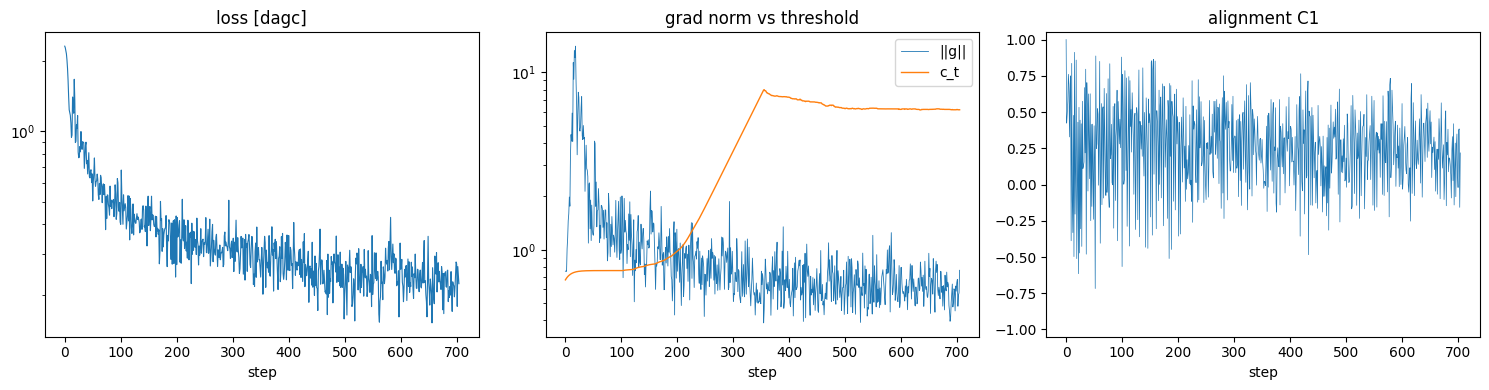

In [5]:
# 选一个策略看训练过程（改 POLICY）
POLICY = "dagc"
SEED   = CONFIG["seeds"][0]

r = run_one(POLICY, SEED)

lg = r["log"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
t = np.arange(len(lg["loss"]))
axes[0].plot(t, lg["loss"], lw=0.8); axes[0].set_title(f"loss [{POLICY}]"); axes[0].set_yscale("log")
axes[1].plot(t, lg["grad_norm"], lw=0.6, label="||g||")
axes[1].plot(t, lg["threshold"], lw=1.0, label="c_t"); axes[1].set_yscale("log"); axes[1].legend(); axes[1].set_title("grad norm vs threshold")
axes[2].plot(t, lg["alignment"], lw=0.5); axes[2].set_ylim(-1.05, 1.05); axes[2].set_title("alignment C1")
for ax in axes: ax.set_xlabel("step")
plt.tight_layout(); plt.show()

## 🏃 模块 2：策略对比（A8 雏形）

按 `CONFIG["RUN_WHAT"]` 跑所有策略 × 所有 seeds，自动保存；最后画对比图。


In [6]:
RUNS = {}
for name in CONFIG["RUN_WHAT"]:
    RUNS[name] = []
    for seed in CONFIG["seeds"]:
        RUNS[name].append(run_one(name, seed))

print("\n全部运行完成，结果已保存到", RESULTS)

[none] seed 0 | epochs 3


  epoch 1/3  loss 0.5469  steps 235


  epoch 2/3  loss 0.2877  steps 470


  epoch 3/3  loss 0.2513  steps 705


    done 28.1s | test_acc 90.45% | F_clip 0.000 | N_switch 0
[none] seed 1 | epochs 3


...

    done 29.7s | test_acc 90.79% | F_clip 0.255 | N_switch 43
[dagc] seed 1 | epochs 3


  epoch 1/3  loss 0.6172  steps 235


  epoch 2/3  loss 0.2973  steps 470


  epoch 3/3  loss 0.2417  steps 705


    done 26.9s | test_acc 90.00% | F_clip 0.247 | N_switch 41

全部运行完成，结果已保存到 E:\Paper\Paper_02_Application in AI\Experiments for AI\results\raw


## 📊 监控台：汇总对比（跨策略 × seeds）

读取 `results/raw/` 里所有已保存的运行（包括之前会话的），汇总 mean±std 表 + 对比图。


In [7]:
def load_all_runs():
    runs = {}
    for f in sorted(RESULTS.glob("run_*.json")):
        try:
            d = json.loads(f.read_text())
        except Exception:
            continue
        key = (d["policy"], d["seed"])
        runs[key] = d
    return runs

def dashboard(runs, keys=("test_acc", "f_clip", "i_clip", "n_switch", "mean_c1", "mean_c2", "loss_dom_freq")):
    rows = {}
    for (pol, seed), d in runs.items():
        rows.setdefault(pol, []).append(d)
    print(f"{'policy':<8}" + "".join(f"{k:>12}" for k in keys))
    for pol in sorted(rows):
        vals = {k: [d[k] for d in rows[pol]] for k in keys}
        line = f"{pol:<8}"
        for k in keys:
            a = np.array(vals[k])
            line += f"{a.mean():>9.3f}±{a.std():<3.3f}"
        print(line)
    return rows

all_runs = load_all_runs()
print(f"已加载 {len(all_runs)} 次运行")
rows = dashboard(all_runs)

已加载 6 次运行
policy      test_acc      f_clip      i_clip    n_switch     mean_c1     mean_c2loss_dom_freq
dagc        0.904±0.004    0.251±0.004    0.113±0.001   42.000±1.000    0.207±0.017   -0.087±0.004    0.001±0.000
fixed       0.901±0.005    0.744±0.029    0.255±0.013  210.000±4.000    0.213±0.016   -0.110±0.003    0.001±0.000
none        0.899±0.006    0.000±0.000    0.000±0.000    0.000±0.000    0.194±0.015   -0.010±0.004    0.001±0.000


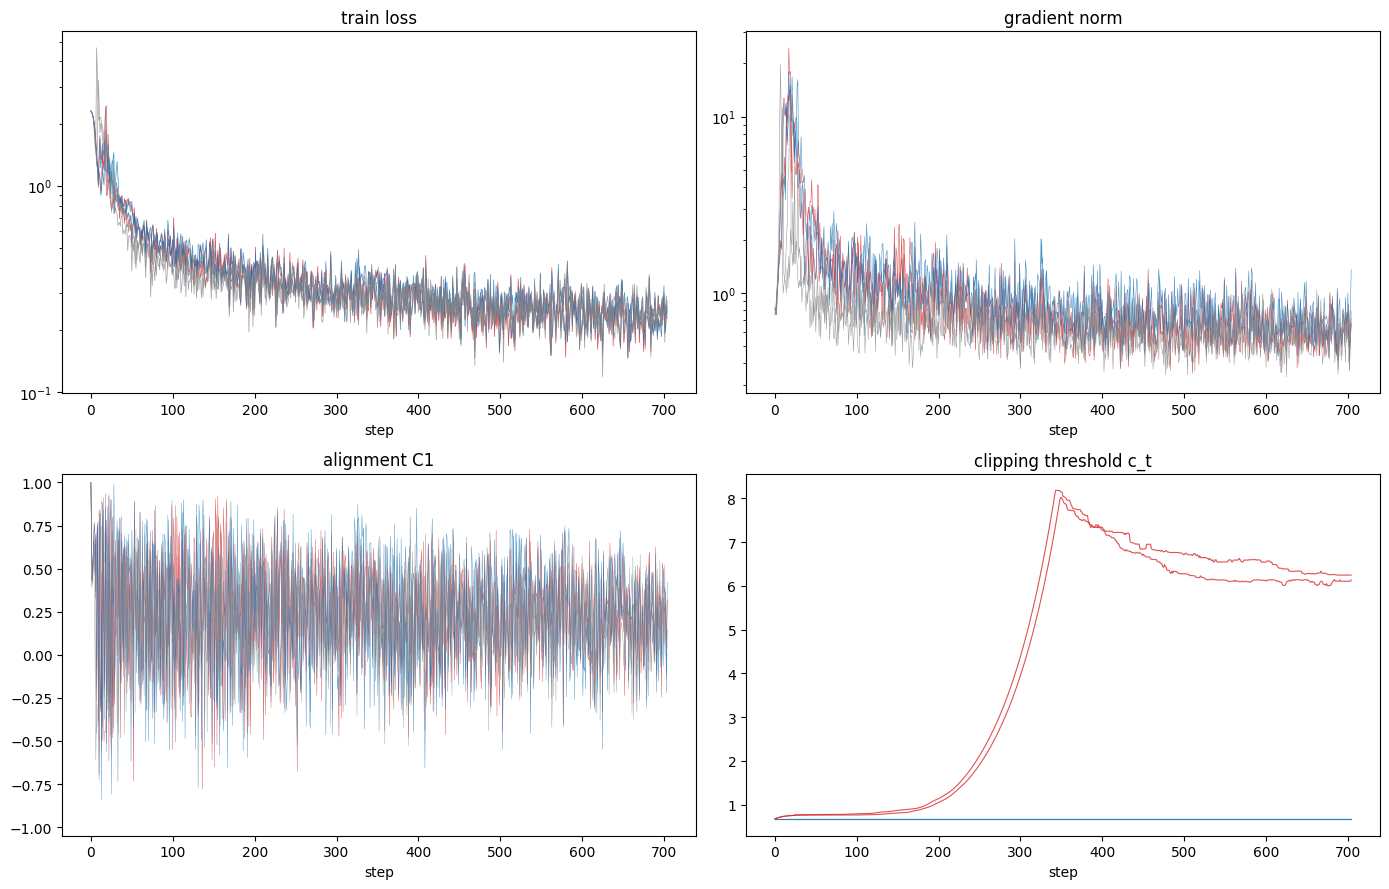

In [8]:
# 监控台可视化：每策略的 loss / 梯度范数 / 对齐度 / 阈值（所有 seeds 叠加）
colors = {"none": "#888888", "fixed": "#1f77b4", "dagc": "#d62728"}
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for (pol, seed), d in all_runs.items():
    lg = d["log"]
    t = np.arange(len(lg["loss"]))
    axes[0, 0].plot(t, lg["loss"], color=colors.get(pol, "k"), lw=0.5, alpha=0.8)
    axes[0, 1].plot(t, lg["grad_norm"], color=colors.get(pol, "k"), lw=0.4, alpha=0.8)
    axes[1, 0].plot(t, lg["alignment"], color=colors.get(pol, "k"), lw=0.3, alpha=0.8)
    axes[1, 1].plot(t, lg["threshold"], color=colors.get(pol, "k"), lw=0.8, alpha=0.8)
axes[0, 0].set_title("train loss"); axes[0, 0].set_yscale("log")
axes[0, 1].set_title("gradient norm"); axes[0, 1].set_yscale("log")
axes[1, 0].set_title("alignment C1"); axes[1, 0].set_ylim(-1.05, 1.05)
axes[1, 1].set_title("clipping threshold c_t")
for ax in axes.flat: ax.set_xlabel("step")
plt.tight_layout(); plt.show()

## 🔬 模块 3：单次运行深度诊断

对一次已保存的运行做暴露/切换/振荡诊断（对应实验 A3 / A4 / A5 的雏形）。


In [9]:
def diagnose(r):
    import numpy as np
    from src.oscillation import dominant_frequency
    from src.switching import switching_crossings, switching_count

    lg = r["log"]
    s = np.array(lg["signed"])
    gn = np.array(lg["grad_norm"])
    th = np.array(lg["threshold"])
    e = (gn > th).astype(float) if r["policy"] != "none" else np.zeros_like(gn)

    # 暴露突发（burst）：连续裁剪的段
    bursts, cur = [], 0
    for v in e:
        if v > 0.5:
            cur += 1
        else:
            if cur: bursts.append(cur)
            cur = 0
    if cur: bursts.append(cur)

    out = {
        "policy": r["policy"],
        "F_clip": float(e.mean()),
        "N_switch": switching_count(s),
        "mean_burst": float(np.mean(bursts)) if bursts else 0.0,
        "max_burst": int(max(bursts)) if bursts else 0,
        "loss_freq": dominant_frequency(lg["loss"]),
        "gn_freq": dominant_frequency(lg["grad_norm"]),
        "n_bursts": len(bursts),
    }
    return out, bursts

d, bursts = diagnose(list(all_runs.values())[-1])
for k, v in d.items():
    print(f"  {k:<12} {v}")
print(f"  burst 分布: {bursts[:20]} ...")

  policy       none
  F_clip       0.0
  N_switch     0
  mean_burst   0.0
  max_burst    0
  loss_freq    0.0014184397163120568
  gn_freq      0.0014184397163120568
  n_bursts     0
  burst 分布: [] ...


## 📖 使用说明

1. **改参数** → 改 CONFIG 单元，然后 Run All（或按模块单独运行）。
2. **单策略调试** → 模块 1（改 `POLICY`）。
3. **正式对比** → 模块 2 + 监控台；多跑几个 seeds 后监控台自动汇总 mean±std。
4. **结果持久化** → 每次运行保存到 `results/raw/run_<policy>_s<seed>.json`，重启 notebook 后监控台仍能汇总。
5. **注意事项**：
   - 小规模演示（epochs=3, lr=0.1）的精度差异没有统计意义；正式结论需要 A1-A9 协议（≥5 seeds、matched-update 对照），见 `docs/experiments_A0_A9.md`。
   - 监控台读的是 `results/raw/` 下**已保存**的结果，不是当前内存。
